In [1]:
import pandas as pd
import sqlite3

con = sqlite3.connect('../data/checking-logs.sqlite')

In [2]:
query = """
SELECT timestamp 
FROM checker
WHERE uid NOT LIKE 'admin_%'
"""
df_commit = pd.read_sql_query(query, con)
df_commit.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


In [3]:
df_commit['date'] = pd.to_datetime(df_commit['timestamp']).dt.date
df_commit = df_commit.drop('timestamp', axis =1)

In [4]:
df_commit.head()

,date
0,2020-04-17
1,2020-04-17
2,2020-04-17
3,2020-04-17
4,2020-04-17


In [5]:
df_grouped_df_commit = df_commit.groupby('date').size().rename('commits')
len(df_grouped_df_commit)

35

In [6]:
df_grouped_df_commit.head()

date
2020-04-17    23
2020-04-18    69
2020-04-19    33
2020-04-20    25
2020-04-21    25
Name: commits, dtype: int64

In [7]:
query = """
SELECT datetime 
FROM pageviews
WHERE uid NOT LIKE 'admin_%'
"""
df_views = pd.read_sql_query(query, con)
df_views.head()

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144


In [8]:
df_views['date'] = pd.to_datetime(df_views['datetime']).dt.date


In [9]:
df_views = df_views.drop('datetime', axis =1)

In [10]:
df_views.head()

,date
0,2020-04-17
1,2020-04-18
2,2020-04-18
3,2020-04-18
4,2020-04-18


In [11]:
df_grouped_df_views = df_views.groupby('date').size().rename('views')
len(df_grouped_df_views)

33

In [17]:
len(df_grouped_df_commit)

35

In [13]:
df = pd.concat([df_grouped_df_views, df_grouped_df_commit], axis=1, join='inner')
len(df)

32

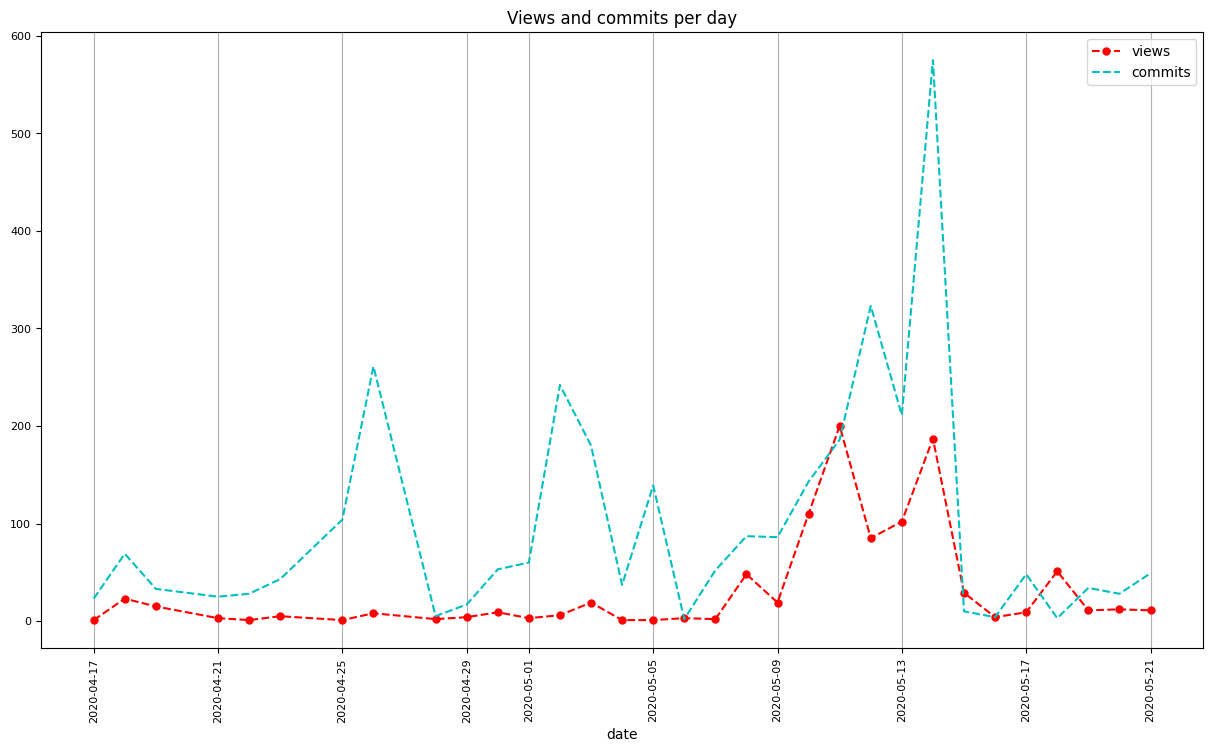

In [14]:
graf = df.plot(
    kind='line',
    figsize=(15, 8),
    fontsize=8,
    title='Views and commits per day',
    rot=90,
    style=['r.--', 'c--'],
    markersize=10
)

graf.grid(axis='x')

In [15]:
con.close()